# Structured Product Assignment B1
*Course year 2025-2026*

This notebook implements a discrete-time delta-hedging framework for a portfolio that is short $n_{\text{calls}}$ European call options on a single underlying stock. The underlying price is simulated under geometric Brownian motion (GBM) on a daily grid (N=252), and option prices and deltas are computed using the Black-Scholes model. Over the life of the option, the hedge is rebalanced daily to match the updated delta, while a cash account accumulates interest at the risk-free rate. The portfolio value is tracked through time to evaluate the performance of the strategy. The analysis is repeated for different configurations (ATM / ITM / OTM) by varying the strike K, while keeping all other market inputs fixed.

**Group 1**<br>
**Rick Hezeman (s3450902)**<br>
**Roy Mulder (s2587572)**<br>
**Jeroen Pouwels (s2389878)**<br>
**Ruben Stevenaar (s2633582)**<br>
**Justus Straus (s2636662)**<br>

## Part A

### A.1. Delta Hedging
Delta hedging is a risk-management practice used when trading options or other derivatives to manage exposure to price movements in the underlying asset (Fliess & Join, 2010). The idea behind delta hedging is to reduce a portfolio's sensitivity to changes in the price of the underlying asset. When an investor holds an option, its value changes as the price of the underlying asset moves. Even if the trader does not directly own the underlying asset, the option still creates exposure to movements in that asset. Delta hedging is used to reduce this exposure by adjusting the trader’s position in the underlying asset.
When the total delta of a portfolio is adjusted to zero, the portfolio is said to be delta-neutral, meaning that small movements in the underlying asset price have little immediate effect on the portfolio’s value (Hull, 2015).
However, an option's delta is not constant; it changes over time and with movements in the underlying asset price, volatility, and time to maturity. As a result, a hedge set up at time 0 will remain accurate for only a short period. To maintain delta neutrality, traders must continuously monitor and adjust their positions in the underlying asset, typically by buying or selling shares. This process is known as dynamic delta hedging, in contrast to a static hedge, which makes no adjustments after the initial setup (Hull, 2015). In practice, hedging strategies often use discrete time steps, such as daily closing, to rebalance positions (Fliess & Join, 2010). 
### A.2. Purpose
The purpose of dynamic delta hedging is to reduce directional price exposure created by holding or writing an option. By keeping the portfolio approximately delta-neutral, the trader aims to reduce the impact of small movements in the underlying asset price (Fliess & Join, 2010).
### A.3. Limitations
Despite its usefulness, dynamic delta hedging has several practical limitations. First, transaction costs can accumulate from frequent rebalancing, which may reduce the effectiveness of the hedge (Hull, 2015). Second, liquidity risk can arise during periods of market stress, when it becomes difficult or expensive to trade the underlying asset to maintain the hedge. Finally, the effectiveness of delta hedging depends on model assumptions, so incorrect modelling of the underlying asset's dynamics can lead to imperfect hedging (Hull, 2015).
### A.4. Stakeholders
Several stakeholders are involved in or affected by dynamic delta hedging. Traders, investors, and portfolio managers use delta hedging to reduce exposure to price movements in the underlying asset and to manage portfolio risk. Risk-management teams monitor whether exposures are properly hedged and ensure that risk limits are respected. Quantitative analysts develop and maintain pricing models that calculate option deltas, which are essential for effective hedging. Option buyers and counterparties indirectly benefit from more stable and reliable risk management by financial institutions. 

Finally, regulators are stakeholders because financial institutions must manage derivative risks responsibly and comply with regulations related to risk management, reporting, and derivatives trading, such as the Dodd-Frank Act in the USA (Hull, 2015).

## Part B
### B.1. Code setup

Below, we initialise the Python environment used throughout the assignment. The dynamic delta-hedging simulation relies on:
- numpy for vectorised numerical computations and random number generation.
- matplotlib for producing the required plots.
- scipy.stats.norm to access the standard normal CDF/PDF, required for computing Black-Scholes option values and deltas.

To ensure that results are reproducible, we set a fixed random seed.

In [12]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd

In [13]:
np.random.seed(34)  # Set seed for reproducibility

### B.2. Variable Setup

We next define the baseline parameters for the hedging model. The objective is to dynamically delta-hedge a short position in European call options over a one-year horizon using daily rebalancing. The underlying stock price is modelled under geometric Brownian motion (GBM), and option prices/deltas are computed using the Black-Scholes model.

In [14]:
"""Dynamically delta hedge portfolio of short call options"""
S = 100  # Initial stock price
r = 0.0276  # Risk-free rate (10-year German bond yield)
# K = 100  # Strike price, ATM option
T = 1  # Expiration date, in years
N = 252 # Number of trading days in a year         
dt = T / N # Time increment per trading day
sigma = 0.20 # Annualized volatility (20%)
n_calls = 1  # Number of call options in the portfolio

### B.3. Plotting the hedge dynamics

To interpret the hedging results and verify that the strategy behaves as expected, we define a function that produces the key diagnostics required for this assignment. In a discrete-time delta-hedging framework, delta and the associated stock position are updated every trading day. The plots below make it possible to visually check:
1. Option delta over time $\Delta_t$: how the hedge ratio changes with the stock price and time-to-maturity.
2.	Underlying stock path $S_t$ vs. strike $K$: useful to see when the option becomes ITM/OTM during the simulation.
3.	Number of stocks traded per rebalance: daily adjustment size required to maintain delta neutrality.
4.	Cumulative stock position: the running hedge position held in the underlying.

These charts serve as a consistency check and to interpret the hedging dynamics, as described in Section B.6.

In [15]:
def plot_results(t, array_t, array_delta, array_price, array_strike, array_position, array_nr_stocks):
    """Plot (i) portfolio delta, (ii) stock price, (iii) #stocks traded and
       (iv) stock position over time"""

    # Convert arrays
    array_t_plot = array_t[0:t]
    array_delta_plot = array_delta[0:t]
    array_price_plot = array_price[0:t]
    array_strike_plot = array_strike[0:t]
    array_position_plot = array_position[0:t]
    array_nr_stocks_plot = array_nr_stocks[0:t]

    fig, axes = plt.subplots(nrows=2, ncols=2)
    fig.tight_layout(h_pad=1)

    # Define plots
    delta_plot, = axes[0, 0].plot(array_t_plot, array_delta_plot)
    price_plot, = axes[0, 1].plot(array_t_plot, array_price_plot)
    strike_plot, = axes[0, 1].plot(array_t_plot, array_strike_plot)
    stocks_plot, = axes[1, 0].plot(array_t_plot, array_nr_stocks_plot)
    position_plot, = axes[1, 1].plot(array_t_plot, array_position_plot)

    # Define axis labels
    axes[0, 0].set(xlabel="Day", ylabel="Delta")
    axes[0, 1].set(xlabel="Day", ylabel="Stock price")
    axes[1, 0].set(xlabel="Day", ylabel="# stocks traded")
    axes[1, 1].set(xlabel="Day", ylabel="Long position")

    # Set axis ranges
    axes[0, 0].set_ylim([-1, 1])
    axes[1, 1].set_ylim([-0.1, 1.1 * n_calls])
    axes[1, 0].set_ylim([-0.1, 10 * n_calls])  # If needed, adjust this range

    # Define legends
    axes[0, 1].legend([price_plot, strike_plot], ["Stock", "Strike"])

    plt.show()

### B.4. Option pricing, delta calculation and price path simulation

We now implement the quantitative building blocks used in the delta-hedging simulation:
	1.	Black-Scholes call price $C(S_t, K, r, \sigma, \tau)$, which provides the model value of the European call at each rebalancing date.
	2.	Black-Scholes call delta $\Delta(S_t, K, r, \sigma, \tau)$, which is the hedge ratio used to construct the delta-neutral position in the underlying.
	3.	Geometric Brownian Motion (GBM) dynamics for the underlying stock price under the risk-neutral measure, discretised on a daily grid.

Here $\tau$ denotes the remaining time to maturity. For numerical stability and to avoid division-by-zero at expiry, we include explicit handling for $\tau \le 0$: the option price is set to its intrinsic value and the delta is set to its terminal (maturity) limit (0 or 1 depending on whether the option expires OTM or ITM).

Finally, we generate standard normal shocks $z_t \sim \mathcal{N}(0,1)$ and use them to simulate a single GBM price path:
$S_{t+\Delta t} = S_t \exp\Big((r - \tfrac{1}{2}\sigma^2)\Delta t + \sigma \sqrt{\Delta t}\, z_t\Big)$.
This simulated path is the underlying input that drives option values, deltas, and hedge rebalancing throughout the remainder of the notebook.

In [16]:
def bs_price_call(S, K, r, sigma, tau):
    "BS price of a European call option"
    if tau <= 0:
        return max(S - K, 0)  # Option has expired, return intrinsic value
    else:
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
        d2 = d1 - sigma * np.sqrt(tau)
        return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)


def bs_delta_call(S, K, r, sigma, tau):
    "BS delta of a European call option"
    if tau <= 0:    
        if S > K:
            delta_option = 1.0 # ITM
        elif S < K:
            delta_option = 0.0 # OTM
        else:
            delta_option = 0.5   # ATM 
        return delta_option
    else:
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
        return float(norm.cdf(d1))

z = np.random.normal(0.0, 1.0, size=N)

def GBM(S: float, r: float, sigma: float, dt: float, z: np.ndarray) -> np.ndarray:
    "Simulate Geometric Brownian Motion (GBM) stock price paths"
    price_change = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

    Stock_price = np.zeros(N+1)
    Stock_price[0] = S
    for t in range(1, N + 1):
        Stock_price[t] = Stock_price[t - 1] * price_change[t - 1]
    # Return the simulated stock price path
    return Stock_price


### B.5. Dynamic delta hedging

#### B.5.1. Variable initialization
Before running the hedging loop, we initialise arrays to store the full time series of the simulation on the daily grid $\{0,1,\dots,N\}$. This ensures that we can analyse the hedge behaviour over time, generate the required plots, and compute summary performance metrics at the end of the run.

In [17]:
def delta_hedge(K, S=S, r=r, sigma=sigma, T=T, N=N, dt=dt, n_calls=n_calls):
    
    # Initialize arrays
    array_t = np.zeros(N+1)
    array_delta = np.zeros(N+1)
    array_price = np.zeros(N+1)
    array_strike = np.zeros(N+1)
    array_position = np.zeros(N+1)
    array_nr_stocks = np.zeros(N+1)
    array_option_delta = np.zeros(N+1)
    array_delta_before = np.zeros(N+1)
    array_rebalance = np.zeros(N+1)
    array_portfolio_value = np.zeros(N+1)
    array_option_value = np.zeros(N+1)
    array_interest_payment = np.zeros(N+1)
    array_total_interest = np.zeros(N+1)
    array_hedge_adjustment = np.zeros(N+1)

    # Initialize portfolio variables
    cash = 0  
    total_interest = 0
    position_long = 0  
    portfolio_value = 0 

    # Compute initial properties of call options
    option0 = bs_price_call(S, K, r, sigma, T)
    cash += option0 * n_calls  # Initial cash from selling the call options
    delta_initial = bs_delta_call(S, K, r, sigma, T) 

    # Simulate stock price path
    array_price[:] = GBM(S, r, sigma, dt, z)

    # Compute initial hedge, initialization
    position_long += delta_initial * n_calls  # Update long stock position based on stocks bought/sold
    long_value = position_long * array_price[0]  # Value of long stock position
    cash -= long_value  # Update cash based on stocks bought/sold
    portfolio_value = cash + long_value - (option0 * n_calls)    # Update value based on stocks bought/sold
    portfolio_delta = position_long - (delta_initial * n_calls)  # Update portfolio delta
    adjust_hedge = abs(position_long) # Update hedge
    array_option_value[0] = option0 * n_calls
    array_option_delta[0] = delta_initial
    array_interest_payment[0] = 0.0
    array_total_interest[0] = total_interest
    array_hedge_adjustment[0] = adjust_hedge

    # Print initial output (these are always useful in this context)
    print('\n======= Initial =======')
    print('Stock price %.2f' % S)
    print('Strike price %.2f' % K)
    print('Option value %.2f' % option0) 
    print('Long position %.2f' % position_long)
    print('Total transactions %.2f' % abs(adjust_hedge))  # Nr. of transactions
    print('long_value: %.2f' % long_value)
    print('Portfolio value %.2f' % portfolio_value)
    print('Delta %.2f' % portfolio_delta)
    print('Cash position %.2f' % cash)

    # Store data at t=0
    array_t[0] = 0
    array_delta[0] = portfolio_delta
    array_strike[:] = K
    array_position[0] = position_long  
    array_nr_stocks[0] = abs(adjust_hedge)  
    array_portfolio_value[0] = portfolio_value  

    # Simulate portfolio updates for time horizon
    for t in range(1, N+1):
        tau = (N - t) * dt  # Time to maturity in years
        array_t[t] = t
        option_value = bs_price_call(array_price[t], K, r, sigma, tau) * n_calls  # Value of option position
        delta_option = bs_delta_call(array_price[t], K, r, sigma, tau)  # Compute new delta of the option
        array_option_value[t] = option_value
        array_option_delta[t] = delta_option
        array_delta_before[t] = array_position[t-1] - delta_option * n_calls

        rebalance = delta_option * n_calls - array_position[t-1]  # Determine how much to rebalance

        # Update arrays and portfolio variables
        array_position[t] = array_position[t-1] + rebalance # Update stock positions
        array_delta[t] = array_position[t] - (delta_option * n_calls) 
        long_value = array_position[t] * array_price[t]  # Value of long stock position
        
        adjust_hedge = abs(rebalance)  # Update hedge adjustment
        array_hedge_adjustment[t] = adjust_hedge

        array_nr_stocks[t] = array_nr_stocks[t-1] + adjust_hedge  # Store number of stocks traded
        
        assert np.isclose(array_delta[t], 0.0, atol=1e-10), "Oh no! You did not listen well enough to Wouter and your portfolio is not delta neutral anymore. Please check your code and try again."

        # Interest payments on cash balance, also positive when positive cash balance 
        cash_before = cash
        cash *= np.exp(r * dt)  
        interest_payment = cash - cash_before

        # When actually paying interest, it is a cost
        if cash_before < 0:
            total_interest -= interest_payment   # positive number = interest paid

        array_interest_payment[t] = interest_payment
        array_total_interest[t] = total_interest
                
        cash -= rebalance * array_price[t]  # Update cash balance with cost of rebalancing
        array_portfolio_value[t] = cash + long_value - option_value # Store portfolio value

        # If maturity, close all option and stock positions here and calculate final P&L
        if t == N:
            cash += array_position[t] * array_price[t]
            array_position[t] = 0

            residual = cash - option_value
            array_portfolio_value[t] = residual

    return {
        "K": K,
        "array_t": array_t,
        "array_price": array_price,
        "array_strike": array_strike,
        "array_position": array_position,
        "array_delta": array_delta,
        "array_delta_before": array_delta_before,
        "array_nr_stocks": array_nr_stocks,
        "array_portfolio_value": array_portfolio_value,
        "total_interest": total_interest,             
        "array_option_value": array_option_value,
        "array_option_delta": array_option_delta,
        "array_interest_payment": array_interest_payment,
        "array_total_interest": array_total_interest,
        "array_hedge_adjustment": array_hedge_adjustment
    }

In [18]:
results_K100 = delta_hedge(K=100)

for t in range(1, N+1):
    print("\n--- Hedging step ---")
    print(f"Day {t}")
    print(f"Stock price: {results_K100['array_price'][t]:.2f}")
    print(f"Option value: {results_K100['array_option_value'][t]:.2f}")
    print(f"Option delta: {results_K100['array_option_delta'][t]:.4f}")
    print(f"Hedge adjustment: {results_K100['array_hedge_adjustment'][t]:.4f}")
    print(f"Long position: {results_K100['array_position'][t]:.4f}")
    print(f"Delta after hedge: {results_K100['array_delta'][t]:.6f}")
    print(f"Cumulative transactions: {results_K100['array_nr_stocks'][t]:.4f}")
    print(f"Portfolio value: {results_K100['array_portfolio_value'][t]:.2f}")
    print(f"Interest payment: {-results_K100['array_interest_payment'][t]:.4f}")
    print(f"Total interest payments: {results_K100['array_total_interest'][t]:.4f}")

    if t == N:
        print()
        print(f"At maturity: option payoff (short) = {-results_K100['array_option_value'][t]:.2f}")
        print(f"Residual after closing stock + settling option = {results_K100['array_portfolio_value'][t]:.2f}")


======= Initial =======
Stock price 100.00
Strike price 100.00
Option value 9.29
Long position 0.59
Total transactions 0.59
long_value: 59.41
Portfolio value 0.00
Delta 0.00
Cash position -50.11

--- Hedging step ---
Day 1
Stock price: 100.31
Option value: 9.46
Option delta: 0.5999
Hedge adjustment: 0.0058
Long position: 0.5999
Delta after hedge: 0.000000
Cumulative transactions: 0.5999
Portfolio value: 0.01
Interest payment: 0.0055
Total interest payments: 0.0055

--- Hedging step ---
Day 2
Stock price: 99.37
Option value: 8.88
Option delta: 0.5814
Hedge adjustment: 0.0185
Long position: 0.5814
Delta after hedge: 0.000000
Cumulative transactions: 0.6184
Portfolio value: 0.02
Interest payment: 0.0056
Total interest payments: 0.0110

--- Hedging step ---
Day 3
Stock price: 97.44
Option value: 7.78
Option delta: 0.5423
Hedge adjustment: 0.0391
Long position: 0.5423
Delta after hedge: 0.000000
Cumulative transactions: 0.6575
Portfolio value: -0.00
Interest payment: 0.0054
Total interest 

#### B.5.2. Defining initial portfolio values

After initializing the model variables, we define their initial values. Hence, we calculate the option price and the corresponding delta at $t=0$. Next, we simulate the GBM stock price path using the previously defined function. We then define the hedge dynamics:

- Long stock position is calculated by multiplying delta with the number of calls, ensuring a cumulative portfolio delta of zero.
- The value of this long position is achieved by multiplying this long position with the current stock price.
- Our cash position is adjusted by subtracting the value of our long position from the initial cash balance.
- Our portfolio value is then calculated by subtracting the value of the sold option from the sum of our cash and long position.
- Our portfolio delta is computed by subtracting the delta of the option multiplied by the number of options (1 in this case) from our long stock position (multiplied by $\Delta=1$ for the underlying).
- The amount by which the hedge is adjusted is equal to the absolute value of our long stock position

These hedge dynamics are stored in their corresponding arrays, which are used to track the hedging process across the entire time horizon. Using a per-day parameter summary and the final plots, we can analyse whether the hedge performs appropriately and as expected.

#### B.5.3. Dynamic delta hedging of a portfolio

Lastly, we run the core simulation: a discrete-time delta hedging strategy with daily rebalancing over the horizon $t=1,...,N$. For every day, we calculate $\tau$ as the remaining time-to-maturity. Also, we compute the price and delta of the option at that specific time, and we rebalance the portfolio with an adjustment in long position, calculated by subtracting our previous long position from the current option delta. After adding this rebalance variable to our previous long position, we obtain our new long position. By subtracting the current option delta from this long position, we find our current portfolio delta. Then, similarly as when initializing the variables, we obtain the long value by multiplying our long position with the current stock price and our hedge adjustment is equal to the absolute value of our rebalance variable. Next, the cumulative number of stocks traded is adjusted by adding the hedge adjustment. To check whether delta fluctuates around zero for each time step, we introduce an assert warning, telling the user whenever delta drifts too far from zero, indicating an error in the model.

To be able to work with interest rates on borrowed money, we introduce a cash balance, which was already previously initialized. To increase our long position, we need to use money subject to interest rates. Hence, we exponentially discount the cash position of the previous time step using the interest rate and calculate the interest payment from the difference between the discounted and undiscounted cash position. Interest payments are also cumulated daily to find the yearly interest rate payment. Then, the cash position is updated by subtracting the value of the adjustment in long position at time $t$ and the portfolio value is recalculated by subtracting the value of the sold options from the sum of this cash position and the current value of the long stock position.

Finally, at maturity, the entire stock position is sold and the cash balance is updated using the value of this position at maturity. The option payoff is then settled and the residual hedging error of the portfolio is represented by the remaining cash balance.

### B.6. Results
The graphs below describe the dynamic hedging dynamics within our portfolio. On the top-right the portfolio delta over time is described. We see a slight fluctuation around zero, which is exactly what we would expect. The option delta is of the previous day is used to rebalance the portfolio back to a delta of zero by buying stocks. Since the option delta slightly varies per day due to a change in time-to-maturity, this will not result in the portfolio delta being constant at zero, but it should stay close to it. 

The next graph, on the top-right, shows the stock price and the strike price throughout the year. Using this graph, we can easily track where the call option is in-, at-, or out-of-the-money. When the the stock price is above the strike price, the call option is in-the-money and when it is below, it is out-the-money. This graph serves to interpret the graph on the bottom-right more easily.

Also, we track the cumulative number of stocks traded. The increasing blue line in the bottom-left figure displays this figure throughout the year. It gives an indication of the activity that is needed to perform a dynamic delta hedge on a single option throughout a year. 

The figure on the bottom-right is the most interesting one. It shows the evolution of the long stock position that is required to keep the portfolio close to delta-neutral. Because we are hedging a call option, the hedge consists of holding a positive amount of stock, and the position size closely follows the option delta. When the stock trades below the strike (out-of-the-money), the call delta is relatively small, so the hedge requires only a moderate stock position. As the stock price moves towards and above the strike (at- and in-the-money), the call delta increases and becomes more sensitive to price changes, so the hedge ratio rises and we need to buy additional shares to cover the increasing option exposure. This explains why the long position gradually trends upward over time and approaches values close to 1 when the option is clearly in-the-money. In that region, the call behaves more like the underlying itself, meaning the hedge must look increasingly like one-for-one stock exposure.

We also observe that the position does not solely increase: whenever the stock price temporarily declines back towards the strike, the option delta decreases again and the hedge is partially unwound, which shows up as a dip in the long position. Finally, the sharp drop at the end reflects the closing of the hedge at maturity. Once the option expires, the delta hedge is no longer needed and the remaining stock position is reduced back to zero.

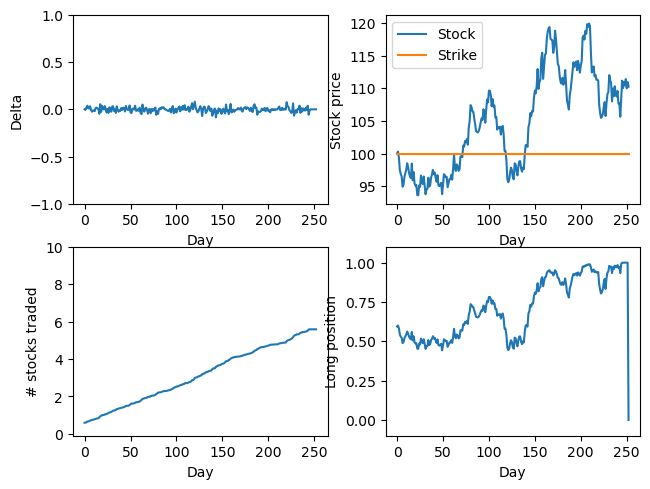

In [19]:
# Plot results
plot_results(
    N+1,
    results_K100["array_t"],
    results_K100["array_delta_before"],
    results_K100["array_price"],
    results_K100["array_strike"],
    results_K100["array_position"],
    results_K100["array_nr_stocks"]
)

## Part C 
### C.1. Extending hedge for ITM and OTM call options 

In part B, we performed the dynamic delta hedge for an ATM European call option with strike price K = 100. In this part we use the same dynamic delta hedge fucntion, as we used for b, for moderately OTM (K=110) and moderately ITM (K=95) call options. 

In this way we can compare the hedge behaviour for ATM, ITM and OTM call options under the the same simulated market environment. By doing so, we can check how the option's moneyness, which refers to the relationship between the underlying asset price and the strike price of an option (Hull, 2018), affects the initial hedge ratio, the amount of trading required over time, and the final hedging perofrmance. 

### C.2. Code explanation 

The code in part C uses the 'delta_hedge(K)'function defined in part B. We only change the strike price K. 

The code performs the following steps: 
1. It re-runs the delta-hedging simulation for a call whith strike K=100, we do this so we can compare results more easily at the end.
2. Plot the results: Portfolio delta before rebalancing, stock price path, cumulative stocktrades, and stockposition over time. 
3. It runs the delta-hedging simulation for an OTM call with strike K=110
4. Plots the results for K=110
5. It runs the delta-hedging simulation for an ITM call with strike K=95
6. Plots the results for K=95
7. We finally provide a comparison table so we can interpret results and compare between the different strike prices 

All three cases are evaluated on the same simulated stock price path. Since the underlying stock paths which follows a GBM are are kept identical, any difference in the plots or hedging outcomes can only be atributed to the different strike prices. This makes the compariosn between the ITM, ATM and OTM call options more meaningfull. 


======= Initial =======
Stock price 100.00
Strike price 100.00
Option value 9.29
Long position 0.59
Total transactions 0.59
long_value: 59.41
Portfolio value 0.00
Delta 0.00
Cash position -50.11


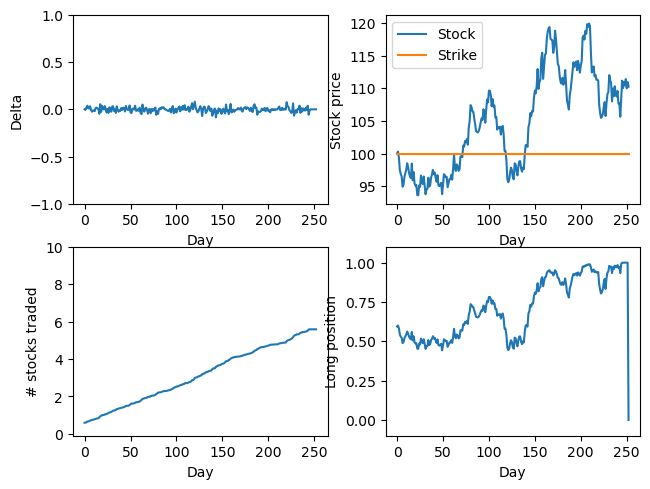


======= Initial =======
Stock price 100.00
Strike price 200.00
Option value 0.00
Long position 0.00
Total transactions 0.00
long_value: 0.06
Portfolio value 0.00
Delta 0.00
Cash position -0.06


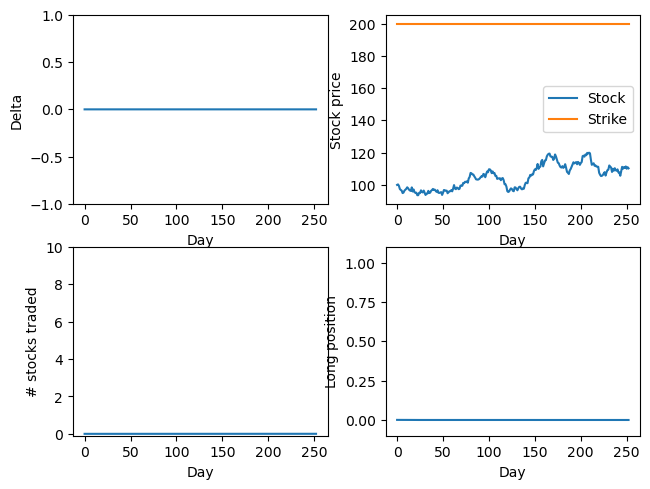


======= Initial =======
Stock price 100.00
Strike price 50.00
Option value 51.36
Long position 1.00
Total transactions 1.00
long_value: 99.99
Portfolio value 0.00
Delta 0.00
Cash position -48.63


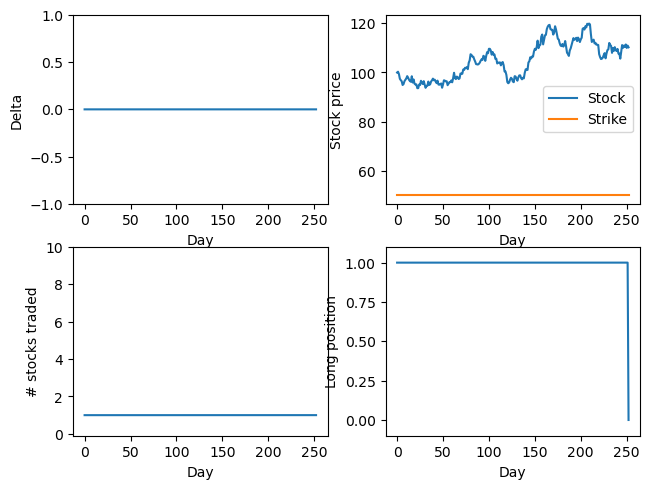

                           K=95 (ITM)  K=100 (ATM)  K=110 (OTM)
Metric                                                         
Strike (K)                     50.000      100.000      200.000
Moneyness (S0/K)                2.000        1.000        0.500
Initial option delta            1.000        0.594        0.001
Initial stock position          1.000        0.594        0.001
Max |delta before hedge|        0.000        0.084        0.000
Mean |delta before hedge|       0.000        0.020        0.000
Total shares traded             1.001        5.591        0.003
Average hedge adjustment        0.004        0.022        0.000
Total interest paid             1.361        1.825        0.000
Final residual P&L              0.000        0.011        0.000
                         K=95 (ITM) K=100 (ATM) K=110 (OTM)
Metric                                                     
Max |delta after hedge|   0.000e+00   0.000e+00   2.118e-22
Mean |delta after hedge|  0.000e+00   0.000e+00   1.

In [28]:
"Plot K=100 for the ease of comparising"
results_K100 = delta_hedge(K=100)

plot_results(
    N+1,
    results_K100["array_t"],
    results_K100["array_delta_before"],
    results_K100["array_price"],
    results_K100["array_strike"],
    results_K100["array_position"],
    results_K100["array_nr_stocks"]
)

results_K110 = delta_hedge(K=200)

plot_results(
    N+1,
    results_K110["array_t"],
    results_K110["array_delta_before"],
    results_K110["array_price"],
    results_K110["array_strike"],
    results_K110["array_position"],
    results_K110["array_nr_stocks"]
)

results_K95 = delta_hedge(K=50)

plot_results(
    N+1,
    results_K95["array_t"],
    results_K95["array_delta_before"],
    results_K95["array_price"],
    results_K95["array_strike"],
    results_K95["array_position"],
    results_K95["array_nr_stocks"]
)

S0 = S

comparison_table = pd.DataFrame({
    "Metric": [
        "Strike (K)",
        "Moneyness (S0/K)",
        "Initial option delta",
        "Initial stock position",
        "Max |delta before hedge|",
        "Mean |delta before hedge|",
        "Max |delta after hedge|",
        "Mean |delta after hedge|",
        "Total shares traded",
        "Average hedge adjustment",
        "Total interest paid",
        "Final residual P&L"
    ],

    "K=95 (ITM)": [
        results_K95["K"],
        S0 / results_K95["K"],
        results_K95["array_option_delta"][0],
        results_K95["array_position"][0],
        np.max(np.abs(results_K95["array_delta_before"])),
        np.mean(np.abs(results_K95["array_delta_before"])),
        np.max(np.abs(results_K95["array_delta"])),
        np.mean(np.abs(results_K95["array_delta"])),
        results_K95["array_nr_stocks"][-1],
        np.mean(results_K95["array_hedge_adjustment"]),
        results_K95["array_total_interest"][-1],
        results_K95["array_portfolio_value"][-1]
    ],

    "K=100 (ATM)": [
        results_K100["K"],
        S0 / results_K100["K"],
        results_K100["array_option_delta"][0],
        results_K100["array_position"][0],
        np.max(np.abs(results_K100["array_delta_before"])),
        np.mean(np.abs(results_K100["array_delta_before"])),
        np.max(np.abs(results_K100["array_delta"])),
        np.mean(np.abs(results_K100["array_delta"])),
        results_K100["array_nr_stocks"][-1],
        np.mean(results_K100["array_hedge_adjustment"]),
        results_K100["array_total_interest"][-1],
        results_K100["array_portfolio_value"][-1]
    ],

    "K=110 (OTM)": [
        results_K110["K"],
        S0 / results_K110["K"],
        results_K110["array_option_delta"][0],
        results_K110["array_position"][0],
        np.max(np.abs(results_K110["array_delta_before"])),
        np.mean(np.abs(results_K110["array_delta_before"])),
        np.max(np.abs(results_K110["array_delta"])),
        np.mean(np.abs(results_K110["array_delta"])),
        results_K110["array_nr_stocks"][-1],
        np.mean(results_K110["array_hedge_adjustment"]),
        results_K110["array_total_interest"][-1],
        results_K110["array_portfolio_value"][-1]
    ]
}).set_index("Metric")

print(comparison_table.loc[
    ["Strike (K)", "Moneyness (S0/K)", "Initial option delta", "Initial stock position", "Max |delta before hedge|", "Mean |delta before hedge|", "Total shares traded", "Average hedge adjustment", "Total interest paid", "Final residual P&L"]
].round(3))

print(comparison_table.loc[
    ["Max |delta after hedge|", "Mean |delta after hedge|"]
].apply(lambda col: col.map(lambda x: f"{x:.3e}"))
)

### C.3. Interpretation of results 
The results are mostly in line with our expectations:  
- First, the initial hedge position differs clearly across the different strike prices. The ITM options starts with the highest delta en therefore requires the largest initial stock long position to offset the short call exposure. The ATM requires a smaller hedge, while the OTM option requires the lowest initial stock position. This is exactly what we would expect from the Black-Scholes theory. Which states that a call that is more deeply ITM has a higher delta because its value behaves more like the underlying stock. Conversely, an OTM call had a lower delta, because the probability of ending ITM is smaller. Therefore, as expected, the initial option delta and stock position is the same for the three options.   

- Second, the portfolio delta before hedging is around zero in all cases. This, in addition with the top left plot shows that the hedge is working as intended. Each day the portfolio is brought back to a neutral delta which can be seen at the last two lines of the table. Between rebalancing moments the option delta changes dueo to movements in the stock price and reduction in time to maturity. This reflects the small deviations from zero before the next rebalances, which are in line with our expectations for a discrete hedging framework. 

- Third, the cumulative number of stocks traded differs across the three strike prices. We initially would expect that the total shares traded would be the highest for the ATM option since it requires more active adjustments over time because delta respond more strongly to changes in the underlying price. In our case the OTM case shows substantial hedge activity because near maturity the stock ends up very close to its strike. When the stock price is close to the strike price near maturity, even small movements in the underlying can significantly change the probability that the option ends ITM. As a result the option delta can shift quickly between values close 0 and close to 1. This behaviour is captured by the options gamma, which measures how fast delta changes with respect to the underlying price. Gamma is highest for ATM options near maturity, meaning that small price movements lead to large changes in delta. Because our strategy aims to keep the portfolio delta nuetral, the rapid changes in delta require frequent adjustments of the hedge position resulting in a larger number of rebalancing trades. This behaviour of delta is also visualized in the top left corner of the second plot, the bottom right corner shows the rapid changing position in the stock near maturity. The bottem left corner of the second plot shows the strong incline of cumulative stocks traded near maturity. This shows that moneyness at time zero does not fully determine the total tradig volume over the life of the option. What matters is the full path of the stock price relative to the strike price. An initially OTM can still generate strong hedge dynamics if the stock path approaches the strike later in the simulation. This is especially true for moderately ITM and OTM options.However, if we would choose K very large (200) or very small (50). There would be no trading for the OTM option during the lifetime of the option. For the ITM case the initial stock position would be 1 without any additional trading activity during the life of the option.  

- Finally **Discuss total interest paid and P&L**

delta after hedge checken + Waarom P&L niet hetzelfde? 

## Authors' contribution



## AI Statement
